# 1. Discrete Laplacian and the Heat Equation

## Objectives
Prerequisites: Basic calculus, finite differences, and Python/NumPy.

In this notebook, we develop the numerical foundation for the remainder of the project. We begin by constructing the one-dimensional discrete Laplacian with periodic boundary conditions and use it to solve the heat equation with an explicit Euler scheme.

Along the way, we verify that the discrete operator reproduces known analytical results before applying it to numerical simulations. The numerical methods introduced here will be reused throughout the remainder of the project, where we extend the deterministic heat equation to stochastic partial differential equations, culminating in the Parabolic Anderson Model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Mathematical Background

### Periodic Boundary Conditions

Throughout this project, we consider functions on a periodic domain. In the discrete setting, this means that the left and right endpoints are identified, so every grid point always has two neighbors.

NumPy's `np.roll` provides a convenient way to shift an array while automatically wrapping around the boundary. This allows periodic finite difference operators to be implemented without treating the boundary points separately.

In [2]:
u = np.arange(5)

print("u           =", u)
print("Left shift  =", np.roll(u, -1))
print("Right shift =", np.roll(u, 1))
print("Second diff =", np.roll(u, -1) + np.roll(u, 1) - 2*u)

u           = [0 1 2 3 4]
Left shift  = [1 2 3 4 0]
Right shift = [4 0 1 2 3]
Second diff = [ 5  0  0  0 -5]


### Constructing the Discrete Laplacian

With periodic shifts available, we can now construct the discrete Laplacian.

For a uniform grid with spacing $h$, the second derivative is approximated by the central finite difference

$$
\Delta_h u_i
=
\frac{u_{i+1}-2u_i+u_{i-1}}{h^2}.
$$

Using `np.roll`, this finite difference stencil can be implemented directly while naturally respecting the periodic boundary conditions.

In [3]:
def laplacian(u, h):
    """Compute the one-dimensional periodic discrete Laplacian."""
    return (np.roll(u, -1) - 2 * u + np.roll(u, 1)) / h**2

### Verifying the Discrete Operator

Before using the discrete Laplacian in a numerical solver, it is useful to verify that it satisfies a few basic properties.

A constant function has zero second derivative, so the discrete Laplacian should also vanish identically. This provides a simple consistency check for the implementation.

In [4]:
u = np.ones(100)
lap_u = laplacian(u, 1)

assert np.allclose(lap_u, 0)
print("✓ Constant functions have zero discrete Laplacian.")

✓ Constant functions have zero discrete Laplacian.


### Comparison with an Analytical Solution

A more informative verification is obtained by comparing the discrete Laplacian with a function whose analytical Laplacian is known exactly.

The function

$$
u(x)=\sin(2\pi x)
$$

satisfies

$$
\Delta u=-(2\pi)^2u.
$$

Comparing the numerical and analytical Laplacians allows us to assess the accuracy of the finite difference approximation.

In [5]:
N = 100
h = 1 / N

x = np.arange(N) * h
u0 = np.sin(2 * np.pi * x)

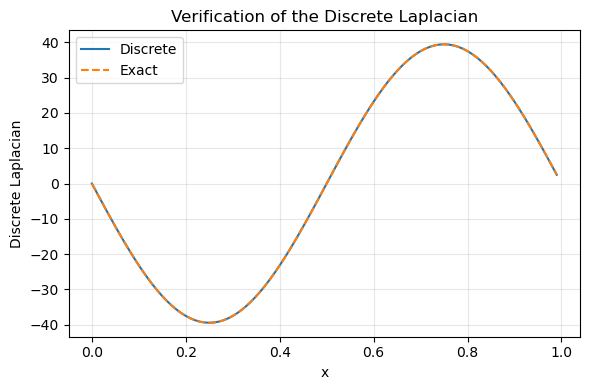

Maximum error = 1.30e-02


In [6]:
lap_u0 = laplacian(u0, h)
exact = -(2 * np.pi)**2 * u0

error = np.max(np.abs(lap_u0 - exact))

plt.figure(figsize=(6, 4))
plt.plot(x, lap_u0, label="Discrete")
plt.plot(x, exact, "--", label="Exact")

plt.xlabel("x")
plt.ylabel("Discrete Laplacian")
plt.title("Verification of the Discrete Laplacian")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Maximum error = {error:.2e}")

## Numerical Method

### Time Discretization

Having verified the spatial discretization, we now introduce a time discretization for the heat equation.

Throughout this notebook, time integration is performed using the explicit Euler method. The time step is chosen proportional to $h^2$, ensuring stability for the chosen spatial discretization.

In [7]:
kappa = 0.5
dt = 0.2 * h**2  # Stable explicit Euler time step

### One Explicit Euler Step

Rather than immediately performing a full simulation, we first examine a single Euler update.

This makes the numerical method explicit and provides a clear connection between the continuous heat equation and its discrete approximation before introducing repeated time stepping.

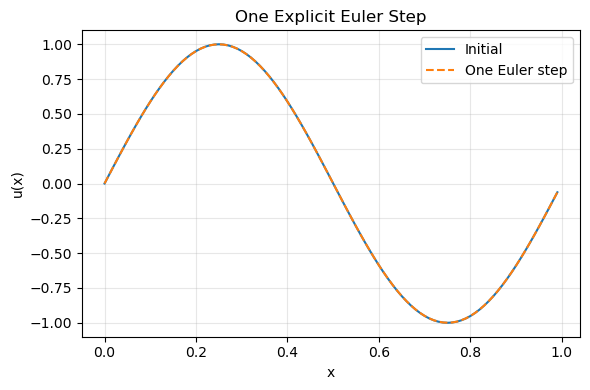

In [8]:
u = u0.copy()

u_new = u + kappa * dt * laplacian(u, h)

plt.figure(figsize=(6, 4))

plt.plot(x, u, label="Initial")
plt.plot(x, u_new, "--", label="One Euler step")

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("One Explicit Euler Step")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Numerical Experiments

### A Reusable Numerical Solver

The explicit Euler update is now encapsulated in a reusable function.

Separating the numerical solver from the experiments improves readability and allows the same implementation to be applied to different initial conditions throughout the remainder of the project.

In [9]:
def solve_heat_equation(u0, h, dt, num_steps, kappa=0.5):
    """
    Solve the one-dimensional heat equation
    using the explicit Euler method.
    """
    u = u0.copy()

    for _ in range(num_steps):
        u += kappa * dt * laplacian(u, h)

    return u

### Example 1: Diffusion of a Sine Wave

We first apply the solver to a sinusoidal initial condition.

Since sine functions are eigenfunctions of the Laplacian, the solution preserves its overall shape while its amplitude decreases over time. This provides another useful check that the numerical solver behaves as expected.

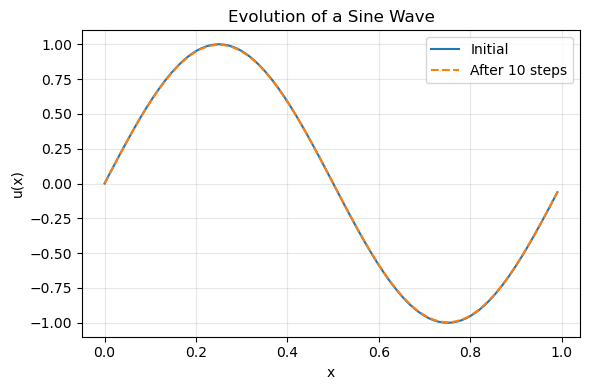

In [10]:
u = solve_heat_equation(
    u0,
    h,
    dt,
    num_steps=10,
    kappa=kappa,
)

plt.figure(figsize=(6, 4))

plt.plot(x, u0, label="Initial")
plt.plot(x, u, "--", label="After 10 steps")

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Evolution of a Sine Wave")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Example 2: Diffusion of a Localized Profile

Our second example considers a localized Gaussian profile.

Unlike the sinusoidal initial condition, the Gaussian gradually spreads across the domain as the simulation evolves. This illustrates the smoothing effect of the heat equation and demonstrates how diffusion transports localized information over time.

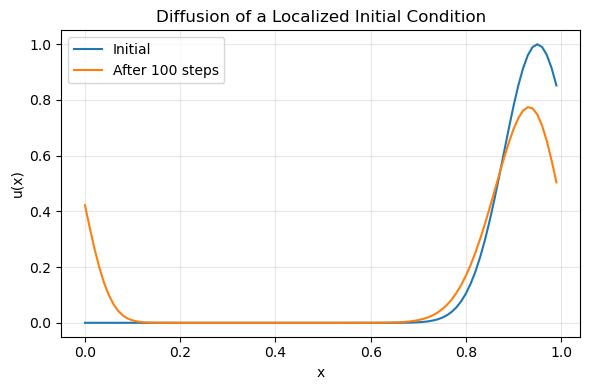

In [11]:
u0 = np.exp(-100 * (x - 0.95)**2)

u = solve_heat_equation(
    u0,
    h,
    dt,
    num_steps=100,
    kappa=kappa,
)

plt.figure(figsize=(6, 4))

plt.plot(x, u0, label="Initial")
plt.plot(x, u, label="After 100 steps")

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Diffusion of a Localized Initial Condition")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In this notebook, we introduced the fundamental numerical tools used throughout the remainder of the project.

Specifically, we

- constructed the periodic discrete Laplacian,
- verified its consistency using analytical test cases,
- implemented the explicit Euler method,
- developed a reusable solver for the heat equation,
- and simulated the evolution of several representative initial conditions.

These numerical components form the foundation for the stochastic models studied in the subsequent notebooks.